# P-ML15 — Optuna Hyperparameter Tuning

**Design locked 2026-04-17** (see `research_log/daily/2026-04-17.md`). Tunes the
**V2-24/7 scaled** champion (Sharpe +1.583, MaxDD −33.6%) by jointly optimising:

- **LightGBM (6 dims):** `n_estimators`, `max_depth`, `learning_rate`,
  `min_child_samples`, `reg_alpha`, `reg_lambda`
- **Positioning (2 dims):** `pred_zscore_window`, `position_scale`

**Inner CV:** shared-study 3-fold purged walk-forward on full 6yr dataset.
Outer 5-fold WF preserved for final reporting — Optuna never sees outer test bars.

**Objective:** mean Sharpe across 3 inner folds (rejected ICIR — F15 showed IC
screens can pass while ensemble Sharpe collapses).

**Budget:** 100 trials, TPE sampler + MedianPruner, ~25 min wall time.

**Decision rule (pre-committed):**
- Lift > +0.15 Sharpe → second pass with wider search space, then re-apply to V2-weekday
- +0.05 ≤ lift ≤ +0.15 → freeze best params, ship to V2-weekday, move to P-ML16
- Lift < +0.05 → P-ML15 done; hand-picked defaults near-optimal; move to P-ML16


In [1]:
import sys
from pathlib import Path
repo_root = Path("__file__").resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt
import optuna

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                      "axes.spines.right": False, "font.size": 9})


In [2]:
# Constants — mirror P-ML13 unified comparison so results are directly comparable.
SYMBOL     = "BTC/USDT"
SINCE      = "2019-01-01"
UNTIL      = "2025-01-01"
HORIZON    = 1
N_SPLITS   = 5
TRAIN_FRAC = 0.6
PURGE      = 1
LONG_MA    = 200
ADX_THRESH = 25.0
MIN_BULL_BARS = 30

FEATURES_V2 = [
    "bar_ret", "bb_zscore", "rsi", "macd_hist_norm", "atr_pct",
    "bb_width", "upper_wick", "lower_wick", "hl_range",
    "vol_log_chg", "di_diff", "adx",
    "ret_5", "ret_20", "mom_zscore_20", "ret_5_minus_20",
]

# Champion baseline (hand-picked, used as comparison anchor)
PRED_ZSCORE_WINDOW = 60
POSITION_SCALE     = 0.5
MAX_POSITION       = 1.0

# Optuna budget
N_TRIALS      = 100
N_INNER_FOLDS = 3
SEED          = 42


## §1 — Build dataset (V2-24/7, 16 features)

In [3]:
from data.fetch import fetch_ohlcv
from ml.features import build_feature_matrix
from ml.features.momentum import build_momentum_features
from ml.labels import forward_return
from ml.regime import RegimeClassifier
from ml.validation import purged_wf_splits
from ml.models import RegimeEnsemble
from backtesting import compute_metrics
from tuning.optuna_regime import tune_regime_ensemble

# Load BTC and build BTC-only features (no cross-asset — V2 is the champion).
df_raw = fetch_ohlcv(symbol=SYMBOL, timeframe="1d", since=SINCE, until=UNTIL)

feats_base = build_feature_matrix(df_raw)
feats_mom  = build_momentum_features(df_raw)
label      = forward_return(df_raw, horizon=HORIZON)
rc         = RegimeClassifier(long_ma=LONG_MA, adx_thresh=ADX_THRESH)
reg        = rc.transform(df_raw)

# Strip tz for alignment.
for s in [feats_base, feats_mom, label, reg]:
    if hasattr(s.index, "tz") and s.index.tz is not None:
        s.index = s.index.tz_localize(None)

comb = pd.concat([feats_base, feats_mom, label, reg["regime"]], axis=1).dropna()

X       = comb[FEATURES_V2]
y       = comb[label.name]
regime  = comb["regime"].fillna("ranging")

# Bar-over-bar log returns aligned with X for equity simulation.
df_raw_naive = df_raw.copy()
df_raw_naive.index = df_raw_naive.index.normalize()
if df_raw_naive.index.tz is not None:
    df_raw_naive.index = df_raw_naive.index.tz_localize(None)
df_raw_naive = df_raw_naive[~df_raw_naive.index.duplicated(keep="last")]

bar_ret = np.log(df_raw_naive["close"].reindex(comb.index) /
                  df_raw_naive["close"].reindex(comb.index).shift(1))
bar_ret = bar_ret.fillna(0)

splits = list(purged_wf_splits(len(comb), N_SPLITS, TRAIN_FRAC, purge_bars=PURGE))

print(f"Dataset:     {len(comb):,} bars | {comb.index[0].date()} -> {comb.index[-1].date()}")
print(f"Outer folds: {N_SPLITS} (rolling, train_frac={TRAIN_FRAC}, purge={PURGE})")
print(f"Bull bars:   {(regime == 'bull').sum():,} ({(regime == 'bull').mean()*100:.1f}%)")


Dataset:     2,132 bars | 2019-03-02 -> 2024-12-31
Outer folds: 5 (rolling, train_frac=0.6, purge=1)
Bull bars:   686 (32.2%)


## §2 — Run the Optuna study (~25 min)

In [4]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

result = tune_regime_ensemble(
    X, y, regime, bar_ret,
    n_trials=N_TRIALS,
    n_inner_folds=N_INNER_FOLDS,
    train_frac=TRAIN_FRAC,
    purge_bars=PURGE,
    min_bull_bars=MIN_BULL_BARS,
    max_position=MAX_POSITION,
    seed=SEED,
    study_name="p_ml15_v2_24_7_scaled",
    show_progress_bar=True,
)

print(f"\nBest inner-CV Sharpe: {result.best_value:+.4f}  ({result.n_trials} trials)")
print("Best params:")
for k, v in result.best_params.items():
    if isinstance(v, float):
        print(f"  {k:<22} {v:.5f}")
    else:
        print(f"  {k:<22} {v}")

n_pruned   = sum(1 for t in result.study.trials if t.state.name == "PRUNED")
n_complete = sum(1 for t in result.study.trials if t.state.name == "COMPLETE")
print(f"\nTrials: {n_complete} complete, {n_pruned} pruned")


  0%|          | 0/100 [00:00<?, ?it/s]


Best inner-CV Sharpe: +1.6119  (100 trials)
Best params:
  n_estimators           450
  max_depth              8
  learning_rate          0.01171
  min_child_samples      49
  reg_alpha              0.51408
  reg_lambda             0.00340
  pred_zscore_window     50
  position_scale         0.46268

Trials: 35 complete, 65 pruned


## §3 — Trial progression + parameter importance

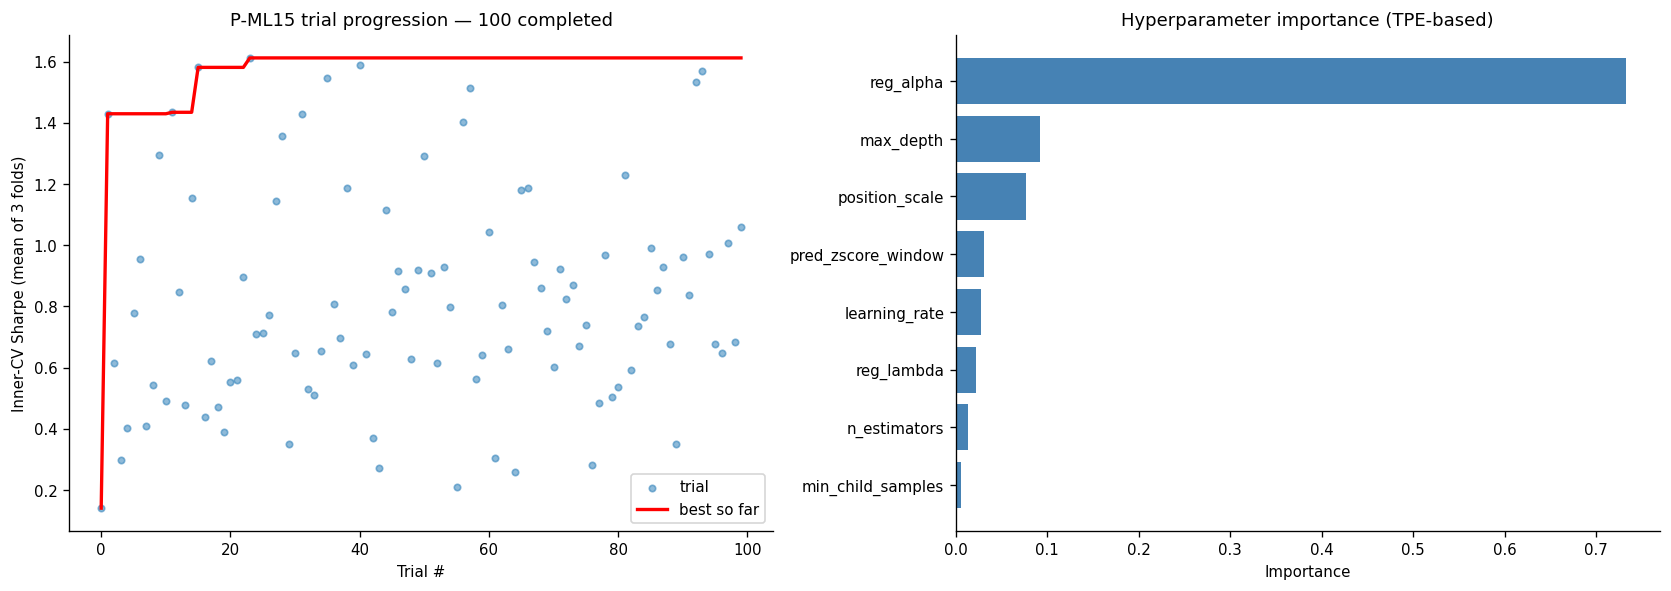

In [5]:
study = result.study

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Trial progression
trials = [t for t in study.trials if t.value is not None]
vals   = [t.value for t in trials]
best_so_far = np.maximum.accumulate(vals) if vals else []

axes[0].scatter(range(len(vals)), vals, s=15, alpha=0.5, label="trial")
if len(vals):
    axes[0].plot(range(len(vals)), best_so_far, color="red", linewidth=2, label="best so far")
axes[0].set_xlabel("Trial #")
axes[0].set_ylabel("Inner-CV Sharpe (mean of 3 folds)")
axes[0].set_title(f"P-ML15 trial progression — {len(vals)} completed")
axes[0].legend()

# (b) Parameter importance
try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()), color="steelblue")
    axes[1].set_xlabel("Importance")
    axes[1].set_title("Hyperparameter importance (TPE-based)")
    axes[1].invert_yaxis()
except Exception as e:
    axes[1].text(0.5, 0.5, f"importance unavailable: {e}", ha="center", va="center",
                 transform=axes[1].transAxes)

plt.tight_layout()
plt.show()


## §4 — Outer 5-fold walk-forward with best params

In [6]:
def _split_params(p):
    pos_keys = {"pred_zscore_window", "position_scale"}
    return ({k: v for k, v in p.items() if k not in pos_keys},
            {k: p[k] for k in pos_keys})


best_model_params, best_pos_params = _split_params(result.best_params)


def run_walk_forward(X, y, regime, bar_ret, splits, model_params):
    folds = []
    for i, (tr, te) in enumerate(splits):
        ens = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS, **model_params)
        ens.fit(X.iloc[tr], y.iloc[tr], regime.iloc[tr])
        preds = ens.predict(X.iloc[te], regime.iloc[te])
        actual = y.iloc[te].values
        ic, _ = stats.spearmanr(preds, actual)
        bull_te = (regime.iloc[te] == "bull").values
        ic_bull = (stats.spearmanr(preds[bull_te], actual[bull_te])[0]
                    if bull_te.sum() > 10 else np.nan)
        folds.append({"fold": i+1, "te": te, "IC": ic, "bull_IC": ic_bull, "preds": preds})
    return folds


def build_equity(folds, bar_ret, idx, mode, pz_win, pos_scale, max_pos):
    pieces, anchor = [], 1.0
    for r in folds:
        te, preds = r["te"], r["preds"]
        if mode == "binary":
            pos = np.sign(preds)
        else:
            pred_s = pd.Series(preds, index=idx[te])
            rm = pred_s.rolling(pz_win, min_periods=1).mean()
            rs = pred_s.rolling(pz_win, min_periods=1).std().replace(0, np.nan)
            pz = (pred_s - rm) / rs
            pos = (pz * pos_scale).clip(-max_pos, max_pos).fillna(0).values

        ret    = bar_ret.iloc[te].values
        pos_sh = np.roll(pos, 1); pos_sh[0] = 0
        eq     = np.cumprod(1 + pos_sh * ret); eq[0] = 1.0
        s      = pd.Series(eq, index=idx[te])
        s      = s / s.iloc[0] * anchor
        anchor = float(s.iloc[-1])
        pieces.append(s)
    return pd.concat(pieces)


# (a) Tuned outer WF
tuned_folds = run_walk_forward(X, y, regime, bar_ret, splits, best_model_params)
tuned_eq_sc = build_equity(tuned_folds, bar_ret, comb.index, "scaled",
                            best_pos_params["pred_zscore_window"],
                            best_pos_params["position_scale"], MAX_POSITION)
tuned_eq_bin = build_equity(tuned_folds, bar_ret, comb.index, "binary",
                             best_pos_params["pred_zscore_window"],
                             best_pos_params["position_scale"], MAX_POSITION)

m_tuned_sc  = compute_metrics(tuned_eq_sc)
m_tuned_bin = compute_metrics(tuned_eq_bin)

ics      = [f["IC"] for f in tuned_folds]
mean_ic  = float(np.mean(ics))
icir     = float(np.mean(ics) / np.std(ics)) if np.std(ics) > 0 else np.nan
bull_ics = [f["bull_IC"] for f in tuned_folds if not np.isnan(f["bull_IC"])]

# (b) Baseline V2-24/7 scaled with hand-picked defaults (champion as of 2026-03-30)
baseline_folds = run_walk_forward(X, y, regime, bar_ret, splits, {})
baseline_eq_sc = build_equity(baseline_folds, bar_ret, comb.index, "scaled",
                                PRED_ZSCORE_WINDOW, POSITION_SCALE, MAX_POSITION)
baseline_eq_bin = build_equity(baseline_folds, bar_ret, comb.index, "binary",
                                 PRED_ZSCORE_WINDOW, POSITION_SCALE, MAX_POSITION)

m_base_sc  = compute_metrics(baseline_eq_sc)
m_base_bin = compute_metrics(baseline_eq_bin)
base_ics   = [f["IC"] for f in baseline_folds]
base_mean_ic = float(np.mean(base_ics))
base_icir    = float(np.mean(base_ics) / np.std(base_ics)) if np.std(base_ics) > 0 else np.nan

# (c) B&H benchmark
bah_close = df_raw_naive["close"].reindex(comb.index)
bah_eq    = bah_close / bah_close.iloc[0]
m_bah     = compute_metrics(bah_eq)


## §5 — Results & decision rule

In [7]:
print("=" * 92)
print("P-ML15 — RESULTS")
print("=" * 92)
print(f"\n{'Config':<44} {'Sharpe':>9} {'Return':>11} {'MaxDD':>9} {'Mean IC':>9} {'ICIR':>7}")
print("-" * 92)
print(f"  {'V2-24/7 scaled (defaults / champion)':<44} {m_base_sc['sharpe_ratio']:>+9.3f} "
      f"{m_base_sc['total_return']*100:>+10.1f}% {m_base_sc['max_drawdown']*100:>+8.1f}% "
      f"{base_mean_ic:>+9.4f} {base_icir:>+7.3f}")
print(f"  {'V2-24/7 scaled (Optuna-tuned)':<44} {m_tuned_sc['sharpe_ratio']:>+9.3f} "
      f"{m_tuned_sc['total_return']*100:>+10.1f}% {m_tuned_sc['max_drawdown']*100:>+8.1f}% "
      f"{mean_ic:>+9.4f} {icir:>+7.3f}")
print(f"  {'V2-24/7 binary (Optuna-tuned)':<44} {m_tuned_bin['sharpe_ratio']:>+9.3f} "
      f"{m_tuned_bin['total_return']*100:>+10.1f}% {m_tuned_bin['max_drawdown']*100:>+8.1f}%")
print(f"  {'V2-24/7 binary (defaults)':<44} {m_base_bin['sharpe_ratio']:>+9.3f} "
      f"{m_base_bin['total_return']*100:>+10.1f}% {m_base_bin['max_drawdown']*100:>+8.1f}%")
print(f"  {'B&H':<44} {m_bah['sharpe_ratio']:>+9.3f} "
      f"{m_bah['total_return']*100:>+10.1f}% {m_bah['max_drawdown']*100:>+8.1f}%")

# Lift on the metric that matters: scaled Sharpe (champion definition)
lift_sharpe = m_tuned_sc["sharpe_ratio"] - m_base_sc["sharpe_ratio"]
lift_maxdd  = m_tuned_sc["max_drawdown"] - m_base_sc["max_drawdown"]   # <0 means smaller DD = better
lift_return = m_tuned_sc["total_return"] - m_base_sc["total_return"]

print(f"\nLift vs hand-picked defaults (scaled mode):")
print(f"  ΔSharpe = {lift_sharpe:+.3f}")
print(f"  ΔMaxDD  = {lift_maxdd*100:+.1f} pp  (negative = smaller drawdown)")
print(f"  ΔReturn = {lift_return*100:+.1f} pp")

print("\n" + "=" * 92)
print("DECISION (pre-committed 2026-04-17)")
print("=" * 92)
if lift_sharpe > 0.15:
    print("→ Lift > +0.15 Sharpe.")
    print("  Action: SECOND PASS with wider search space (add subsample / colsample / num_leaves).")
    print("          Then re-apply best params to V2-weekday for sanity-check.")
elif lift_sharpe >= 0.05:
    print("→ +0.05 ≤ lift ≤ +0.15 Sharpe.")
    print("  Action: FREEZE best params, ship to V2-weekday, move to P-ML16 (expanding-window WF).")
else:
    print("→ Lift < +0.05 Sharpe.")
    print("  Action: P-ML15 DONE. Hand-picked defaults were near-optimal — itself a useful finding.")
    print("          Move to P-ML16 (expanding-window WF) or jump to P-ML19 (on-chain features).")


P-ML15 — RESULTS

Config                                          Sharpe      Return     MaxDD   Mean IC    ICIR
--------------------------------------------------------------------------------------------
  V2-24/7 scaled (defaults / champion)            +1.583     +758.7%    -33.6%   +0.0740  +1.779
  V2-24/7 scaled (Optuna-tuned)                   +0.980     +242.4%    -34.4%   +0.0252  +0.522
  V2-24/7 binary (Optuna-tuned)                   +0.356       +0.9%    -84.8%
  V2-24/7 binary (defaults)                       +1.234    +1815.4%    -77.3%
  B&H                                             +1.166    +2349.0%    -76.6%

Lift vs hand-picked defaults (scaled mode):
  ΔSharpe = -0.604
  ΔMaxDD  = -0.8 pp  (negative = smaller drawdown)
  ΔReturn = -516.3 pp

DECISION (pre-committed 2026-04-17)
→ Lift < +0.05 Sharpe.
  Action: P-ML15 DONE. Hand-picked defaults were near-optimal — itself a useful finding.
          Move to P-ML16 (expanding-window WF) or jump to P-ML19 (on-chain fe

## §6 — Equity overlay

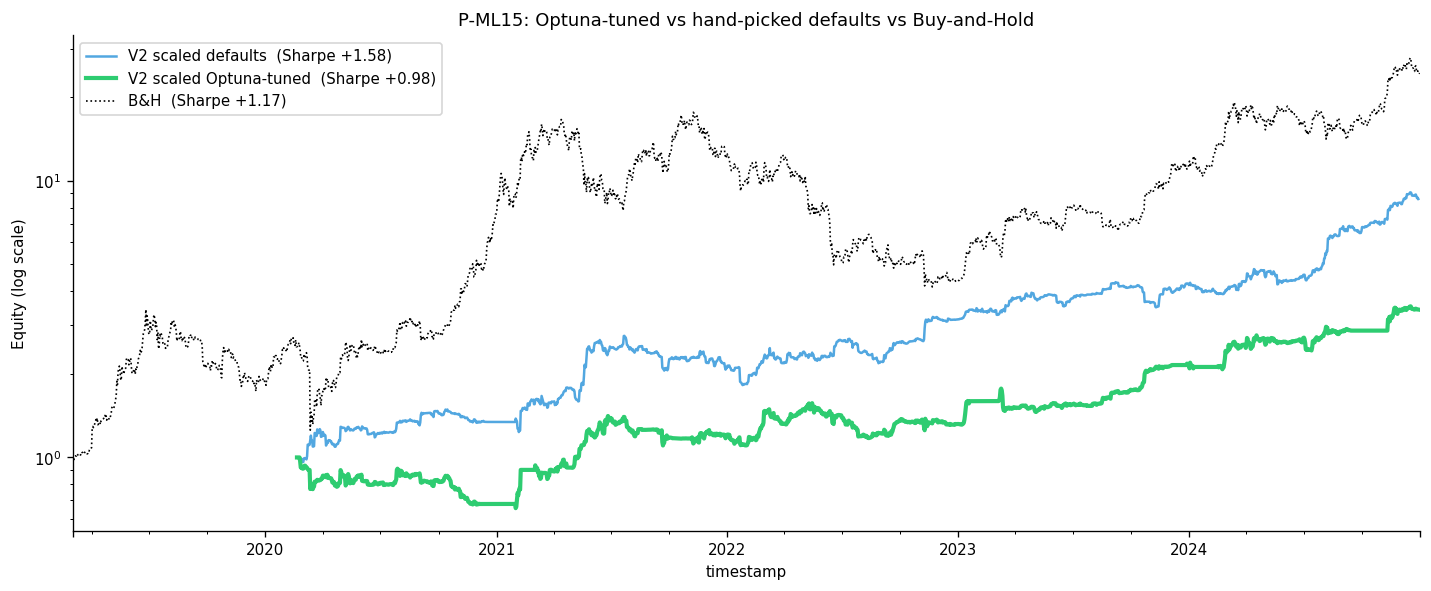

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

baseline_eq_sc.plot(ax=ax, label=f"V2 scaled defaults  (Sharpe {m_base_sc['sharpe_ratio']:+.2f})",
                     color="#3498db", linewidth=1.5, alpha=0.85)
tuned_eq_sc.plot(ax=ax, label=f"V2 scaled Optuna-tuned  (Sharpe {m_tuned_sc['sharpe_ratio']:+.2f})",
                  color="#2ecc71", linewidth=2.5)
bah_eq.plot(ax=ax, label=f"B&H  (Sharpe {m_bah['sharpe_ratio']:+.2f})",
            color="black", linestyle=":", linewidth=1.0)

ax.set_yscale("log")
ax.set_ylabel("Equity (log scale)")
ax.set_title("P-ML15: Optuna-tuned vs hand-picked defaults vs Buy-and-Hold")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()


## §7 — Per-fold IC: tuned vs defaults

In [9]:
print(f"{'Fold':<5} {'Period':<28} {'Defaults IC':>12} {'Tuned IC':>10} {'ΔIC':>7} "
      f"{'Defaults Bull':>14} {'Tuned Bull':>11}")
print("-" * 90)
for i in range(N_SPLITS):
    te = baseline_folds[i]["te"]
    period = f"{comb.index[te[0]].date()} -> {comb.index[te[-1]].date()}"
    ic_d = baseline_folds[i]["IC"]
    ic_t = tuned_folds[i]["IC"]
    b_d  = baseline_folds[i]["bull_IC"]
    b_t  = tuned_folds[i]["bull_IC"]
    b_d_s = f"{b_d:>+14.4f}" if not np.isnan(b_d) else f"{'nan':>14}"
    b_t_s = f"{b_t:>+11.4f}" if not np.isnan(b_t) else f"{'nan':>11}"
    print(f"  {i+1:<3} {period:<28} {ic_d:>+12.4f} {ic_t:>+10.4f} {ic_t-ic_d:>+7.3f} "
          f"{b_d_s} {b_t_s}")

print(f"\n  Mean IC: defaults {base_mean_ic:+.4f}  tuned {mean_ic:+.4f}  ΔICIR "
      f"{icir - base_icir:+.3f}")


Fold  Period                        Defaults IC   Tuned IC     ΔIC  Defaults Bull  Tuned Bull
------------------------------------------------------------------------------------------
  1   2020-02-20 -> 2021-02-08          +0.0721    -0.0699  -0.142            nan         nan
  2   2021-02-09 -> 2022-01-29          +0.0091    +0.0572  +0.048        -0.1278         nan
  3   2022-01-30 -> 2023-01-19          +0.1283    +0.0493  -0.079            nan         nan
  4   2023-01-20 -> 2024-01-09          +0.0537    +0.0552  +0.002        +0.0582         nan
  5   2024-01-10 -> 2024-12-29          +0.1069    +0.0340  -0.073        +0.0714         nan

  Mean IC: defaults +0.0740  tuned +0.0252  ΔICIR -1.257


## §8 — Findings template (fill in after running)

Once the run completes, log the outcome as **F23** in
`research_log/findings.md` and update `research_log/roadmap.md` per the
decision rule above. Suggested F23 skeleton:

```markdown
## F23 — Optuna tuning of V2-24/7 scaled (P-ML15)
**Date:** 2026-05-06 | **Notebook:** `p_ml15_optuna_tuning.ipynb`

100-trial Optuna study (TPE + MedianPruner) on the 7-dim search space
agreed 2026-04-17. Inner CV: 3 purged folds, mean Sharpe objective.
Outer 5-fold WF on full 6yr (2019-2025) for reporting.

**Best params:** `n_estimators=___, max_depth=___, learning_rate=___,
min_child_samples=___, reg_alpha=___, reg_lambda=___,
pred_zscore_window=___, position_scale=___`.

**Result:** Sharpe ___ vs +1.583 baseline (Δ ___). MaxDD ___ vs −33.6% baseline.

**Verdict:** [confirm/reject the +0.10–0.25 Sharpe lift hypothesis;
state which decision-rule branch fires.]

**Next:** [P-ML16 expanding-window OR second-pass wide search OR P-ML19].
```

Also create `research_log/daily/2026-05-06.md` with **Work Done**, **Findings**,
**Open Questions**, **Next Steps**.
